# Email Phishing Detection - Data Analytics

This notebook performs exploratory data analysis (EDA), feature engineering, and predictive modeling on the provided phishing email dataset.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('phishing_email_detection_2026_dataset.csv')

# Basic inspection
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   email_id            1500 non-null   int64 
 1   sender_email        1500 non-null   object
 2   subject             1500 non-null   object
 3   has_link            1500 non-null   int64 
 4   has_attachment      1500 non-null   int64 
 5   urgency_score       1500 non-null   int64 
 6   spelling_errors     1500 non-null   int64 
 7   email_length_words  1500 non-null   int64 
 8   is_phishing         1500 non-null   int64 
dtypes: int64(7), object(2)
memory usage: 105.6+ KB


,email_id,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,750.500000,0.629333,0.512667,5.722667,3.708000,132.559333,0.493333
std,433.157015,0.483144,0.500006,3.002182,3.209819,79.315970,0.500122
min,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,0.000000
25%,375.750000,0.000000,0.000000,3.000000,1.000000,72.000000,0.000000
50%,750.500000,1.000000,1.000000,5.000000,2.000000,108.000000,0.000000
75%,1125.250000,1.000000,1.000000,8.000000,6.000000,193.000000,1.000000
max,1500.000000,1.000000,1.000000,10.000000,10.000000,300.000000,1.000000


In [42]:
# Target variable distribution
print(df['is_phishing'].value_counts())
print(df['is_phishing'].value_counts(normalize=True))  # Percentages

# Feature ranges
print(df[['has_link', 'has_attachment', 'urgency_score', 'spelling_errors', 'email_length_words']].describe())

# Unique senders and subjects
print(f"Unique senders: {df['sender_email'].nunique()}")
print(f"Unique subjects: {df['subject'].nunique()}")


is_phishing
0    760
1    740
Name: count, dtype: int64
is_phishing
0    0.506667
1    0.493333
Name: proportion, dtype: float64
          has_link  has_attachment  urgency_score  spelling_errors  \
count  1500.000000     1500.000000    1500.000000      1500.000000   
mean      0.629333        0.512667       5.722667         3.708000   
std       0.483144        0.500006       3.002182         3.209819   
min       0.000000        0.000000       1.000000         0.000000   
25%       0.000000        0.000000       3.000000         1.000000   
50%       1.000000        1.000000       5.000000         2.000000   
75%       1.000000        1.000000       8.000000         6.000000   
max       1.000000        1.000000      10.000000        10.000000   

       email_length_words  
count         1500.000000  
mean           132.559333  
std             79.315970  
min             20.000000  
25%             72.000000  
50%            108.000000  
75%            193.000000  
max            3

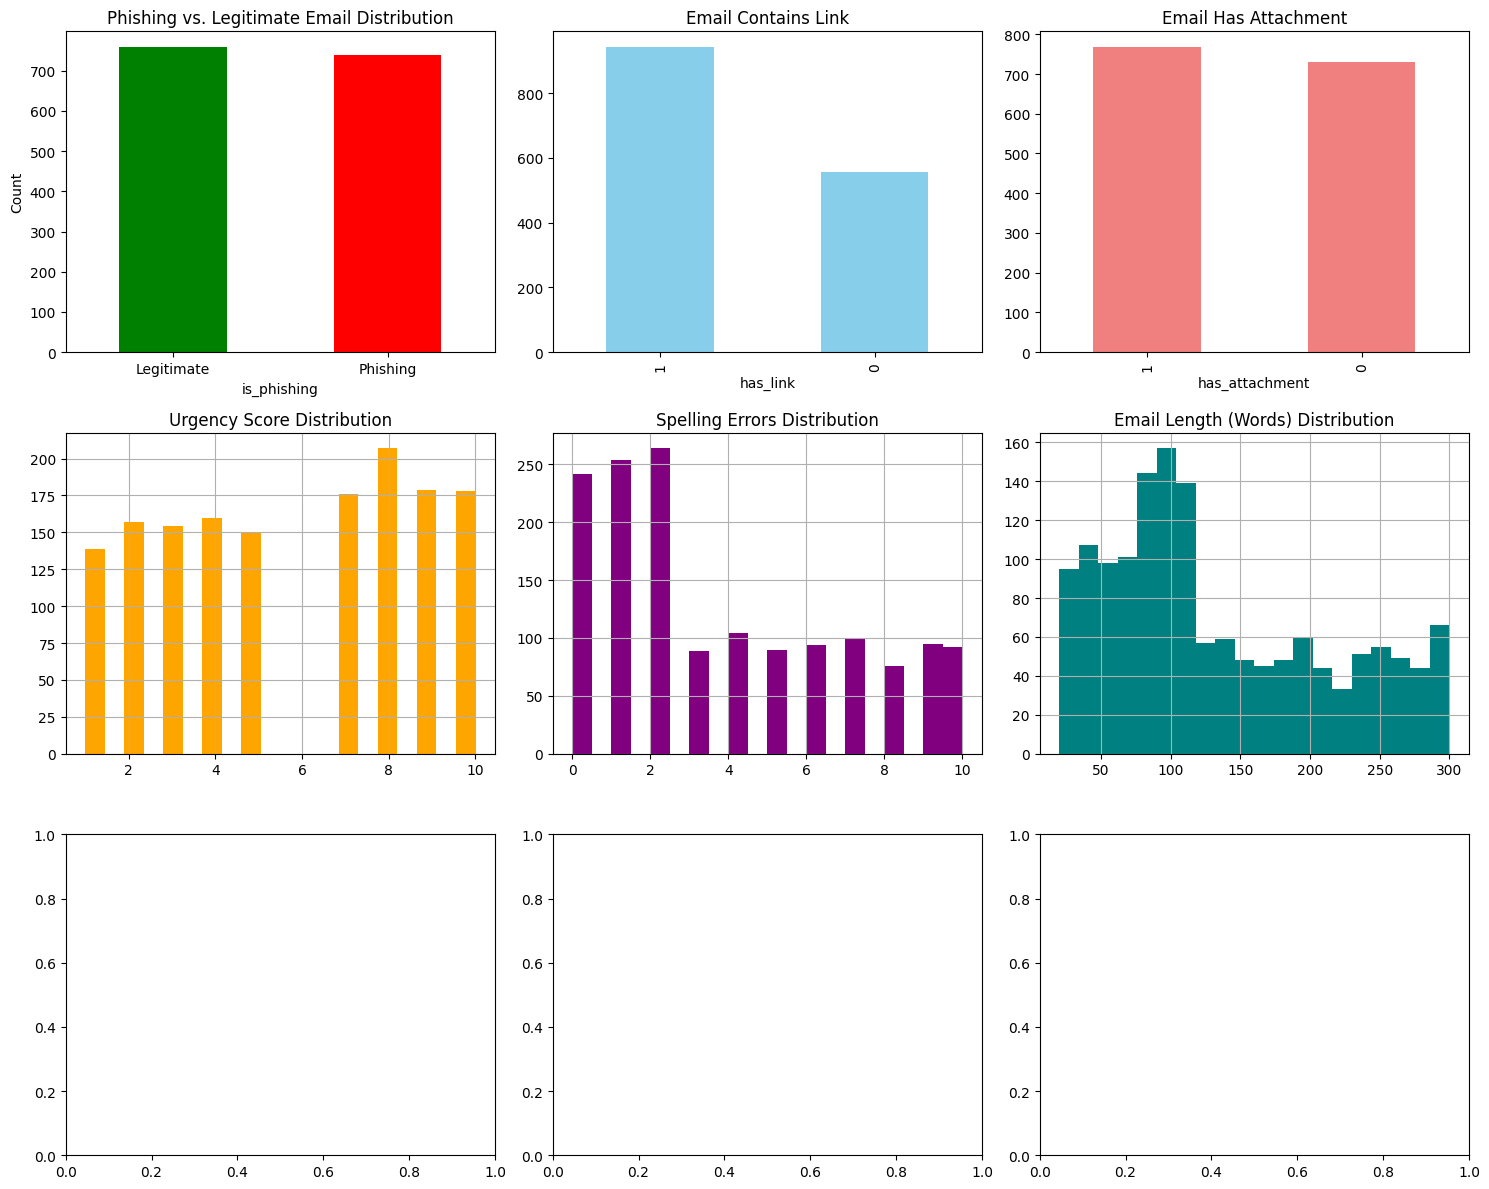

In [43]:
# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Target variable
df['is_phishing'].value_counts().plot(kind='bar', ax=axes[0,0], color=['green', 'red'])
axes[0,0].set_title('Phishing vs. Legitimate Email Distribution')
axes[0,0].set_ylabel('Count')
axes[0,0].set_xticklabels(['Legitimate', 'Phishing'], rotation=0)

# Binary features
df['has_link'].value_counts().plot(kind='bar', ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Email Contains Link')

df['has_attachment'].value_counts().plot(kind='bar', ax=axes[0,2], color='lightcoral')
axes[0,2].set_title('Email Has Attachment')

# Numerical features - distributions
df['urgency_score'].hist(ax=axes[1,0], bins=20, color='orange')
axes[1,0].set_title('Urgency Score Distribution')

df['spelling_errors'].hist(ax=axes[1,1], bins=20, color='purple')
axes[1,1].set_title('Spelling Errors Distribution')

df['email_length_words'].hist(ax=axes[1,2], bins=20, color='teal')
axes[1,2].set_title('Email Length (Words) Distribution')

plt.tight_layout()
plt.show()


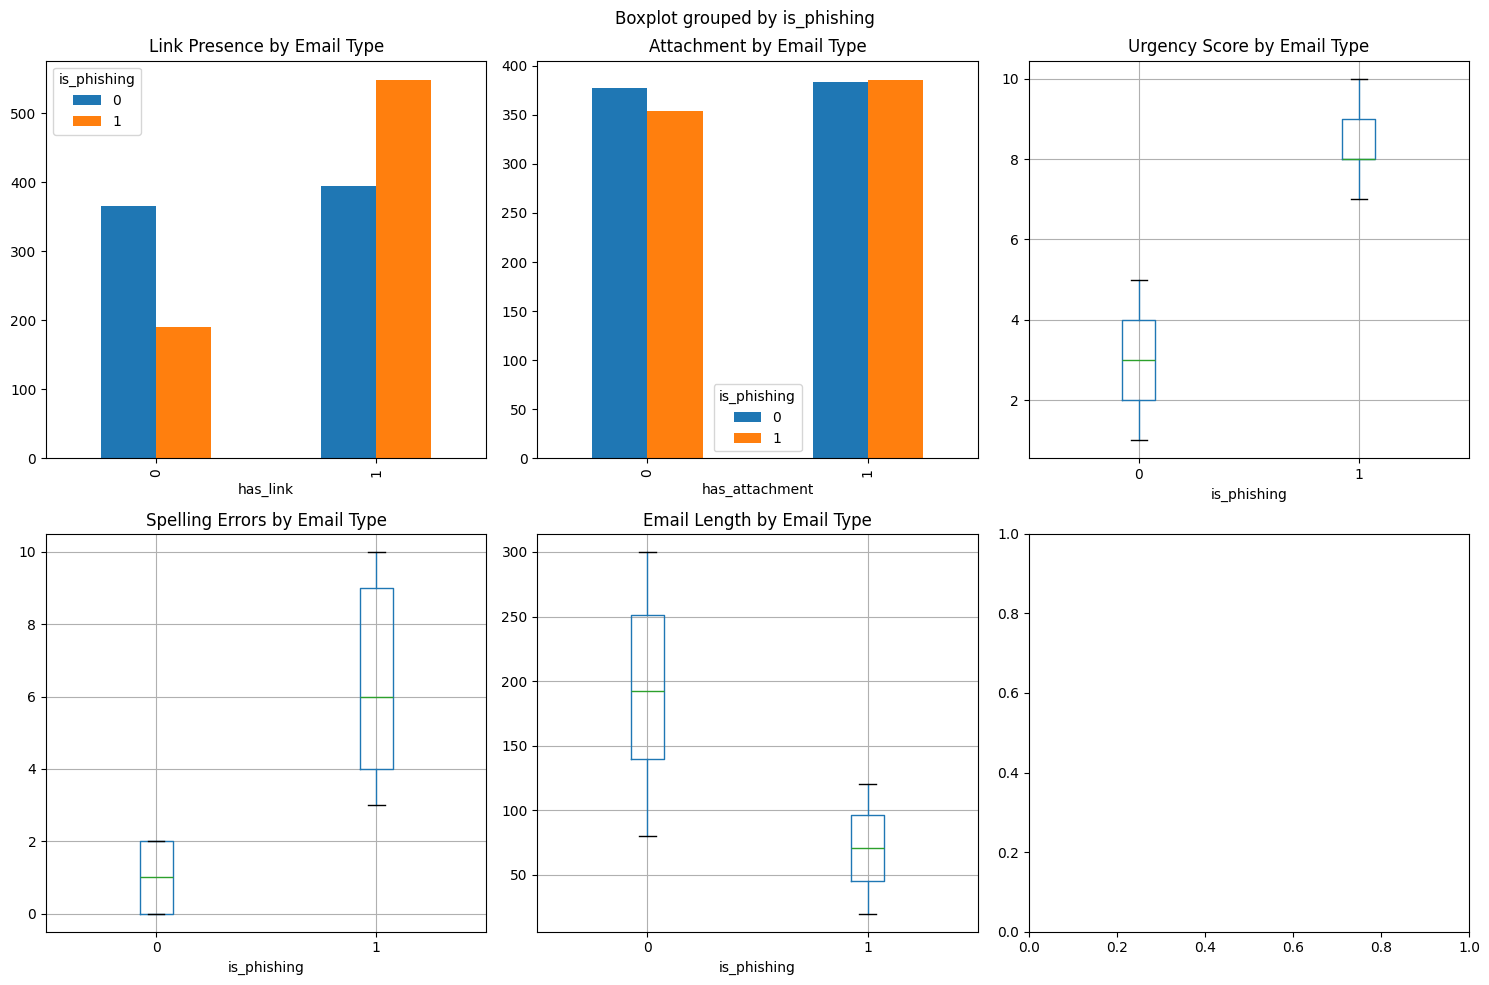

In [44]:
# How do features differ between phishing and legitimate emails?
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Phishing vs. Link presence
pd.crosstab(df['has_link'], df['is_phishing']).plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('Link Presence by Email Type')

# Phishing vs. Attachment
pd.crosstab(df['has_attachment'], df['is_phishing']).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Attachment by Email Type')

# Box plots for continuous features
df.boxplot(column='urgency_score', by='is_phishing', ax=axes[0,2])
axes[0,2].set_title('Urgency Score by Email Type')

df.boxplot(column='spelling_errors', by='is_phishing', ax=axes[1,0])
axes[1,0].set_title('Spelling Errors by Email Type')

df.boxplot(column='email_length_words', by='is_phishing', ax=axes[1,1])
axes[1,1].set_title('Email Length by Email Type')

plt.tight_layout()
plt.show()


In [45]:
# Analyze sender domains
df['sender_domain'] = df['sender_email'].str.split('@').str[1]
print(df['sender_domain'].value_counts().head(10))

# Subject analysis (common words in phishing vs. legitimate)
phishing_subjects = df[df['is_phishing'] == 1]['subject']
legitimate_subjects = df[df['is_phishing'] == 0]['subject']


sender_domain
gmail.com             314
outlook.com           306
paypal-alert.com      304
company-secure.com    299
bankverify.net        277
Name: count, dtype: int64


In [46]:
# Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate email_ids: {df['email_id'].duplicated().sum()}")

# Check for outliers using IQR method
def find_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Check each numerical feature
for col in ['urgency_score', 'spelling_errors', 'email_length_words']:
    outliers = find_outliers(df, col)
    print(f"\n{col} outliers: {len(outliers)}")


Duplicate rows: 0
Duplicate email_ids: 0

urgency_score outliers: 0

spelling_errors outliers: 0

email_length_words outliers: 0


In [47]:
# From sender_email
df['sender_domain'] = df['sender_email'].str.split('@').str[1]
df['is_suspicious_domain'] = df['sender_domain'].isin(['gmail.com', 'yahoo.com', 'hotmail.com']).astype(int)

# From subject
df['subject_length'] = df['subject'].str.split().str.len()
df['has_urgency_keywords'] = df['subject'].str.lower().str.contains(
    'urgent|confirm|verify|update|act now|click here', 
    regex=True, 
    na=False
).astype(int)

# Combine features
df['suspicious_score'] = (df['urgency_score'] + 
                          df['spelling_errors'] + 
                          df['has_link'] + 
                          df['is_suspicious_domain'])

# Print new features
df[['sender_domain', 'is_suspicious_domain', 'subject_length', 
          'has_urgency_keywords', 'suspicious_score']].head()


,sender_domain,is_suspicious_domain,subject_length,has_urgency_keywords,suspicious_score
0,paypal-alert.com,0,2,0,2
1,bankverify.net,0,3,1,17
2,outlook.com,0,3,0,19
3,company-secure.com,0,3,0,17
4,paypal-alert.com,0,4,0,12


In [48]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Create a copy for modeling
df_model = df.copy()

# Drop non-predictive columns (email_id, sender_email, subject - already extracted info)
df_model = df_model.drop(['email_id', 'sender_email', 'subject', 'sender_domain'], axis=1)

# Features and target
X = df_model.drop('is_phishing', axis=1)
y = df_model['is_phishing']

# Scale numerical features (important for algorithms like SVM, KNN, Neural Networks)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after scaling:")
X_scaled.describe()


Features after scaling:


,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_suspicious_domain,subject_length,has_urgency_keywords,suspicious_score
count,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03,1.500000e+03
mean,7.638334e-17,-1.255292e-16,-1.468455e-16,-6.394885e-17,-1.136868e-16,-1.302662e-17,-1.705303e-16,-2.368476e-17,-7.342275e-17
std,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00,1.000334e+00
min,-1.303013e+00,-1.025663e+00,-1.573603e+00,-1.155591e+00,-1.419599e+00,-5.145440e-01,-8.857469e-01,-4.664038e-01,-1.551842e+00
25%,-1.303013e+00,-1.025663e+00,-9.071985e-01,-8.439426e-01,-7.637747e-01,-5.145440e-01,-8.857469e-01,-4.664038e-01,-8.821748e-01
50%,7.674523e-01,9.749796e-01,-2.407941e-01,-5.322947e-01,-3.097425e-01,-5.145440e-01,-8.857469e-01,-4.664038e-01,-3.799245e-01
75%,7.674523e-01,9.749796e-01,7.588124e-01,7.142971e-01,7.622781e-01,-5.145440e-01,3.930022e-01,-4.664038e-01,9.594098e-01
max,7.674523e-01,9.749796e-01,1.425217e+00,1.960889e+00,2.111763e+00,1.943469e+00,1.671751e+00,2.144065e+00,1.963910e+00


Class distribution:
is_phishing
0    760
1    740
Name: count, dtype: int64

Percentages:
is_phishing
0    50.666667
1    49.333333
Name: proportion, dtype: float64


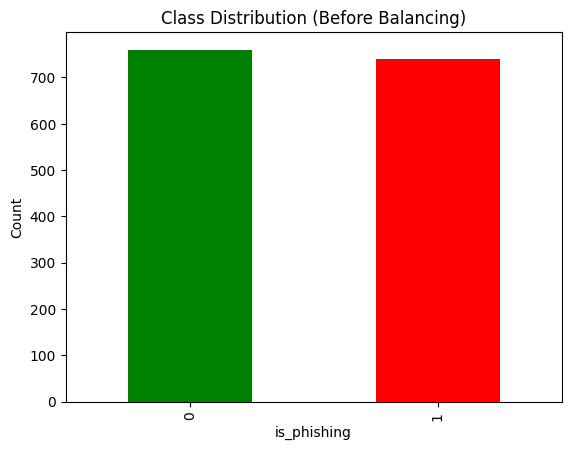

In [49]:
print("Class distribution:")
print(y.value_counts())
print("\nPercentages:")
print(y.value_counts(normalize=True) * 100)

# Visualize
y.value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution (Before Balancing)')
plt.ylabel('Count')
plt.show()


In [50]:
from sklearn.model_selection import train_test_split

# Stratified split (maintains class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Ensures both sets have same class distribution
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTest set class distribution:\n{y_test.value_counts()}")


Training set: 1200 samples
Test set: 300 samples

Training set class distribution:
is_phishing
0    608
1    592
Name: count, dtype: int64

Test set class distribution:
is_phishing
0    152
1    148
Name: count, dtype: int64


In [51]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Check if imbalance exists
imbalance_ratio = y_train.value_counts()[1] / y_train.value_counts()[0]
print(f"Imbalance ratio: {imbalance_ratio:.2%}")

if imbalance_ratio < 0.3:  # Severe imbalance
    # Use SMOTE to oversample minority class
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"\nAfter SMOTE balancing:")
    print(f"Training set size: {len(X_train_balanced)}")
    print(y_train_balanced.value_counts())
else:
    X_train_balanced = X_train
    y_train_balanced = y_train


Imbalance ratio: 97.37%


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

# Dictionary of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test)
    
    # Store predictions for later evaluation
    results[name] = {
        'model': model,
        'y_pred': y_pred
    }
    
    print(f"\n{name} trained successfully")



Logistic Regression trained successfully

Naive Bayes trained successfully

KNN (k=5) trained successfully

Decision Tree trained successfully

Random Forest trained successfully

Gradient Boosting trained successfully

XGBoost trained successfully

SVM trained successfully


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/user/Documents/Bus_Data_Project/emai_phi

In [53]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Tune Random Forest
rf_params = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',  # Use F1 for imbalanced data
    n_jobs=-1
)

rf_grid.fit(X_train_balanced, y_train_balanced)
print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best cross-validation F1 score: {rf_grid.best_score_:.4f}")

# Tune XGBoost
xgb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train_balanced, y_train_balanced)
print(f"\nBest XGBoost parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation F1 score: {xgb_grid.best_score_:.4f}")


Best Random Forest parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best cross-validation F1 score: 1.0000

Best XGBoost parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best cross-validation F1 score: 1.0000


In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    auc
)

# Evaluate all models
evaluation_results = []

for name, result in results.items():
    model = result['model']
    y_pred = result['y_pred']
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of phishing
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    evaluation_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Create comparison dataframe
evaluation_df = pd.DataFrame(evaluation_results).sort_values('F1-Score', ascending=False)
print("\n\nModel Comparison:")
print(evaluation_df.to_string(index=False))



Model: Logistic Regression
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       152
    Phishing       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Model: Naive Bayes
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       152
    Phishing       1.00      1.00      1.00       148

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Model: KNN (k=5)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000
          

/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


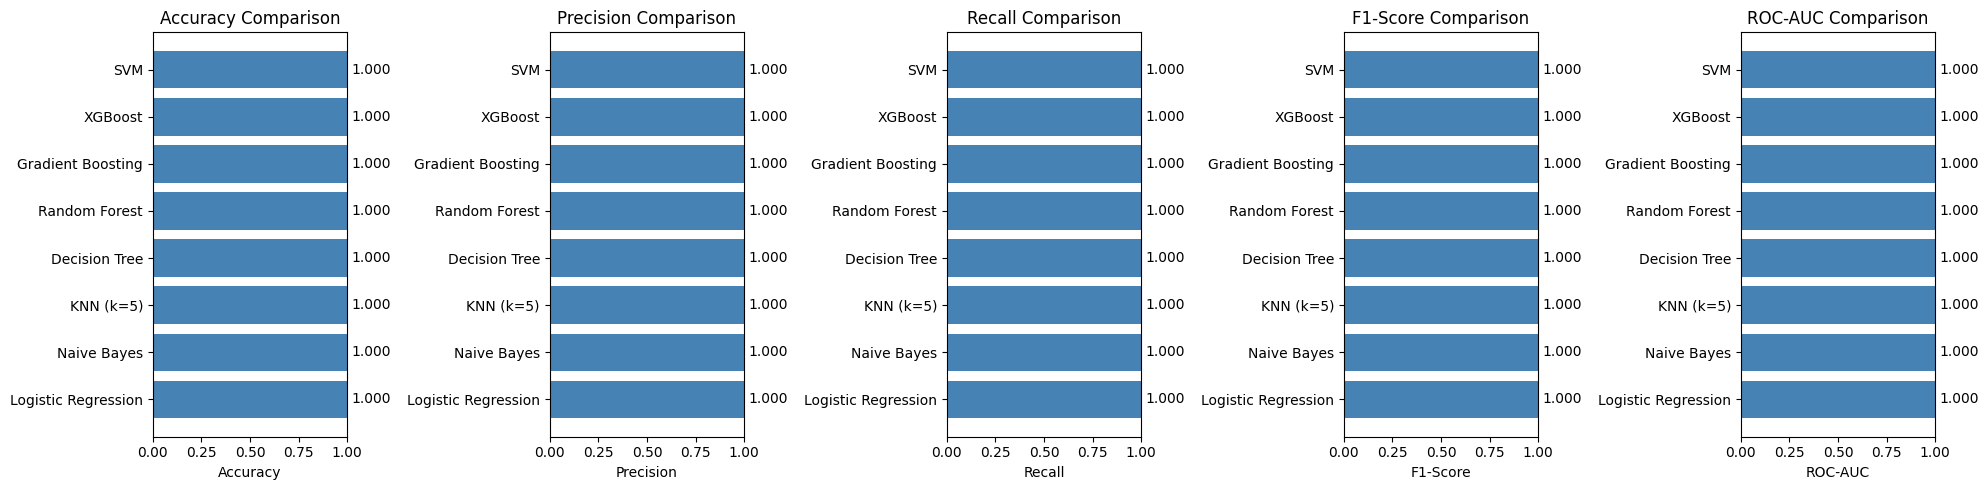

In [55]:
# Bar plot of metrics
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

for idx, metric in enumerate(metrics):
    evaluation_df_sorted = evaluation_df.sort_values(metric, ascending=False)
    axes[idx].barh(evaluation_df_sorted['Model'], evaluation_df_sorted[metric], color='steelblue')
    axes[idx].set_xlabel(metric)
    axes[idx].set_title(f'{metric} Comparison')
    axes[idx].set_xlim([0, 1])
    for i, v in enumerate(evaluation_df_sorted[metric]):
        axes[idx].text(v + 0.02, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


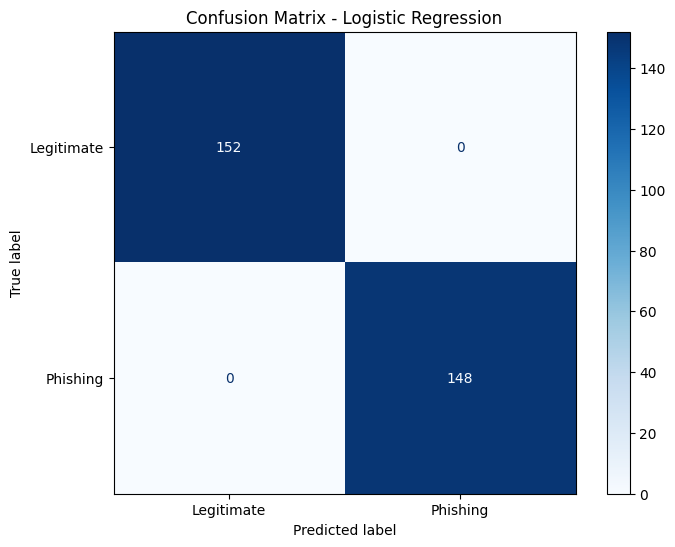


Confusion Matrix Interpretation:
True Negatives (TN):  152 - Legitimate emails correctly identified
False Positives (FP): 0 - Legitimate emails incorrectly flagged as phishing
False Negatives (FN): 0 - Phishing emails that went undetected
True Positives (TP):  148 - Phishing emails correctly identified

False Positive Rate: 0.0000 (0.00%)
False Negative Rate: 0.0000 (0.00%)

Business Impact:
- 0 legitimate emails would be blocked (user frustration)
- 0 phishing emails would slip through (security risk)


In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get best model (highest F1-Score)
best_model_name = evaluation_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = results[best_model_name]['y_pred']

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

print("\nConfusion Matrix Interpretation:")
print(f"True Negatives (TN):  {cm[0,0]} - Legitimate emails correctly identified")
print(f"False Positives (FP): {cm[0,1]} - Legitimate emails incorrectly flagged as phishing")
print(f"False Negatives (FN): {cm[1,0]} - Phishing emails that went undetected")
print(f"True Positives (TP):  {cm[1,1]} - Phishing emails correctly identified")

# Calculate rates
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"\nFalse Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")
print(f"\nBusiness Impact:")
print(f"- {fp} legitimate emails would be blocked (user frustration)")
print(f"- {fn} phishing emails would slip through (security risk)")


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


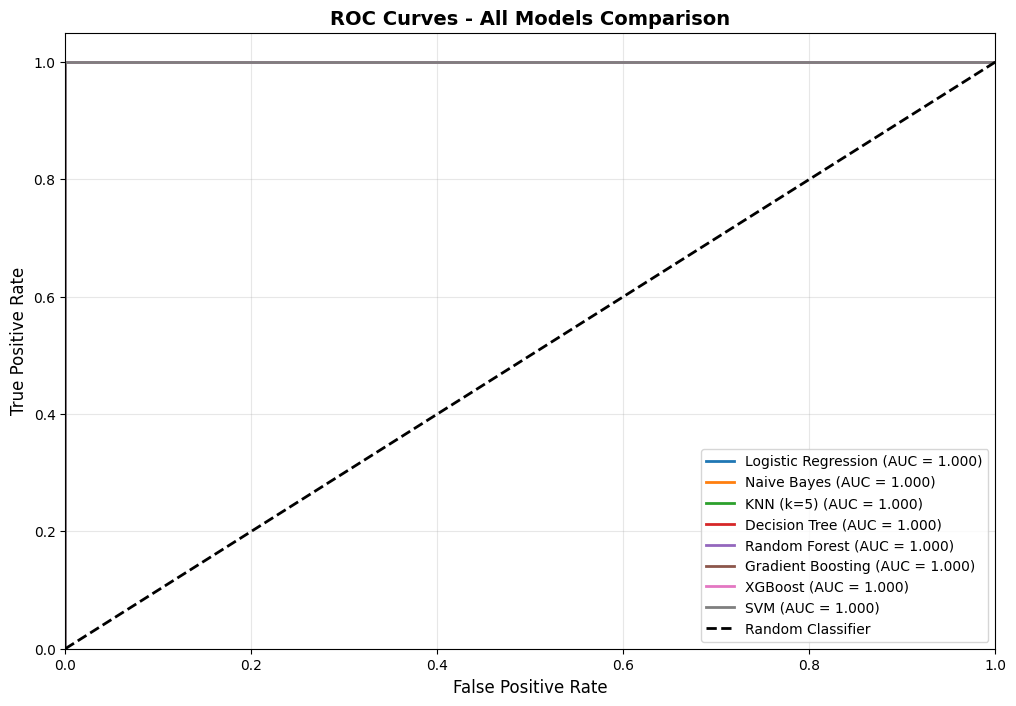

In [57]:
# Plot ROC curves for all models
plt.figure(figsize=(12, 8))

for name, result in results.items():
    model = result['model']
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.show()


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Feature Coefficients - Logistic Regression:
             Feature  Coefficient  Abs_Coefficient
      subject_length     2.361067         2.361067
       urgency_score     1.944713         1.944713
    suspicious_score     1.728605         1.728605
     spelling_errors     1.415316         1.415316
  email_length_words    -1.266346         1.266346
is_suspicious_domain    -0.082808         0.082808
has_urgency_keywords     0.055864         0.055864
            has_link    -0.039299         0.039299
      has_attachment    -0.026553         0.026553


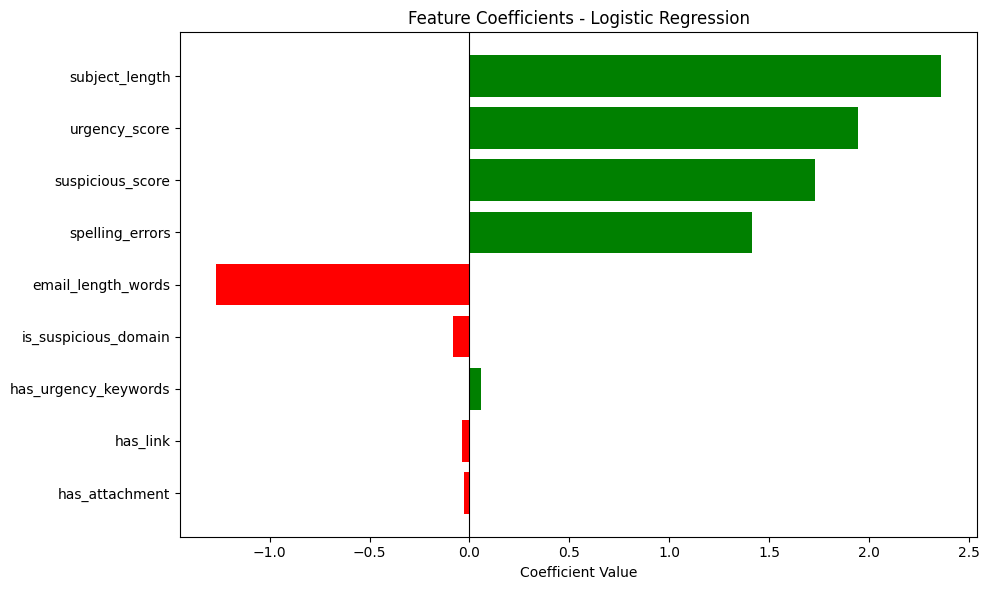

In [58]:
import shap

# Get best model
best_model = results[best_model_name]['model']

# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print(f"\nFeature Importance - {best_model_name}:")
    print(feature_importance.to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
    ax.set_xlabel('Importance Score')
    ax.set_title(f'Feature Importance - {best_model_name}')
    ax.invert_yaxis()
    
    for i, v in enumerate(feature_importance['Importance']):
        ax.text(v + 0.002, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.show()

# For Logistic Regression - coefficients
elif hasattr(best_model, 'coef_'):
    coefficients = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_[0],
        'Abs_Coefficient': np.abs(best_model.coef_[0])
    }).sort_values('Abs_Coefficient', ascending=False)
    
    print(f"\nFeature Coefficients - {best_model_name}:")
    print(coefficients.to_string(index=False))
    
    # Visualize
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['red' if x < 0 else 'green' for x in coefficients['Coefficient']]
    ax.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
    ax.set_xlabel('Coefficient Value')
    ax.set_title(f'Feature Coefficients - {best_model_name}')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.show()



Permutation Importance:
             Feature  Importance      Std
      subject_length    0.024667 0.008055
       urgency_score    0.008000 0.004989
  email_length_words    0.001333 0.002211
    suspicious_score    0.001333 0.001633
            has_link    0.000000 0.000000
      has_attachment    0.000000 0.000000
     spelling_errors    0.000000 0.000000
is_suspicious_domain    0.000000 0.000000
has_urgency_keywords    0.000000 0.000000


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_n

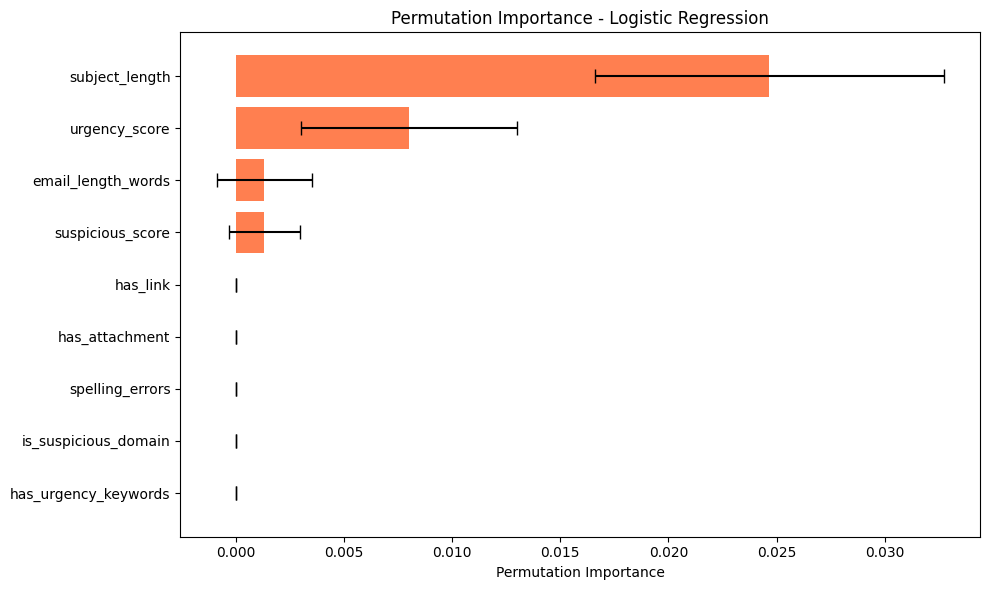

In [59]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values('Importance', ascending=False)

print("\nPermutation Importance:")
print(perm_importance_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], 
        xerr=perm_importance_df['Std'], color='coral', capsize=5)
ax.set_xlabel('Permutation Importance')
ax.set_title(f'Permutation Importance - {best_model_name}')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


  0%|          | 0/100 [00:00<?, ?it/s]/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: divide by zero encountered in matmul
  w = np.linalg.solve(X.T @ WX, WX.T @ y)
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/shap/explainers/_kernel.py:706: RuntimeWarning: overflow encountered in mat

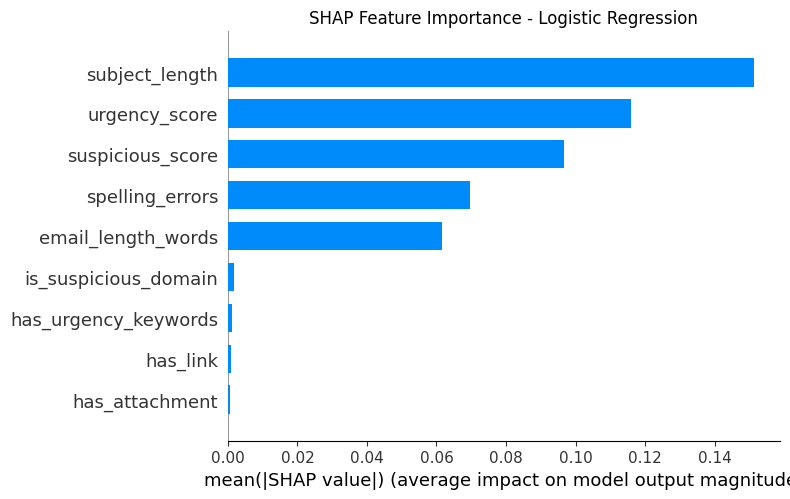

In [60]:
# Install: pip install shap

# Create SHAP explainer
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
    
    # Summary plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
    # Detailed summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, show=False)
    plt.title(f'SHAP Summary Plot - {best_model_name}')
    plt.tight_layout()
    plt.show()
    
else:
    # For other models, use Kernel SHAP
    explainer = shap.KernelExplainer(best_model.predict, X_test.iloc[:100])
    shap_values = explainer.shap_values(X_test.iloc[:100])
    
    shap.summary_plot(shap_values, X_test.iloc[:100], plot_type="bar", show=False)
    plt.title(f'SHAP Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()


In [61]:
# Get misclassified emails
y_pred_best = results[best_model_name]['y_pred']
misclassified = X_test[(y_test != y_pred_best).values]
misclassified_actual = y_test[(y_test != y_pred_best).values]
misclassified_pred = y_pred_best[(y_test != y_pred_best).values]

print(f"\nTotal Misclassifications: {len(misclassified)}")
print(f"Accuracy of best model: {accuracy_score(y_test, y_pred_best):.4f}")

# False Positives (Legitimate flagged as Phishing)
false_positives = misclassified[(misclassified_actual == 0) & (misclassified_pred == 1)]
print(f"\nFalse Positives: {len(false_positives)}")
if len(false_positives) > 0:
    print("False Positive characteristics:")
    print(false_positives.describe())

# False Negatives (Phishing not detected)
false_negatives = misclassified[(misclassified_actual == 1) & (misclassified_pred == 0)]
print(f"\nFalse Negatives: {len(false_negatives)}")
if len(false_negatives) > 0:
    print("False Negative characteristics:")
    print(false_negatives.describe())



Total Misclassifications: 0
Accuracy of best model: 1.0000

False Positives: 0

False Negatives: 0


In [62]:
# Analyze feature patterns in phishing vs. legitimate
print("\n" + "="*70)
print("BUSINESS INSIGHTS - PHISHING vs. LEGITIMATE EMAILS")
print("="*70)

for feature in X.columns:
    phishing_mean = df[df['is_phishing'] == 1][feature].mean()
    legitimate_mean = df[df['is_phishing'] == 0][feature].mean()
    
    print(f"\n{feature}:")
    print(f"  Phishing emails:    {phishing_mean:.2f}")
    print(f"  Legitimate emails:  {legitimate_mean:.2f}")
    print(f"  Difference:         {abs(phishing_mean - legitimate_mean):.2f}")
    
    if phishing_mean > legitimate_mean:
        print(f"  → Phishing emails have HIGHER {feature}")
    else:
        print(f"  → Legitimate emails have HIGHER {feature}")



BUSINESS INSIGHTS - PHISHING vs. LEGITIMATE EMAILS

has_link:
  Phishing emails:    0.74
  Legitimate emails:  0.52
  Difference:         0.22
  → Phishing emails have HIGHER has_link

has_attachment:
  Phishing emails:    0.52
  Legitimate emails:  0.50
  Difference:         0.02
  → Phishing emails have HIGHER has_attachment

urgency_score:
  Phishing emails:    8.49
  Legitimate emails:  3.03
  Difference:         5.45
  → Phishing emails have HIGHER urgency_score

spelling_errors:
  Phishing emails:    6.46
  Legitimate emails:  1.03
  Difference:         5.43
  → Phishing emails have HIGHER spelling_errors

email_length_words:
  Phishing emails:    70.63
  Legitimate emails:  192.86
  Difference:         122.23
  → Legitimate emails have HIGHER email_length_words

is_suspicious_domain:
  Phishing emails:    0.21
  Legitimate emails:  0.21
  Difference:         0.01
  → Legitimate emails have HIGHER is_suspicious_domain

subject_length:
  Phishing emails:    3.40
  Legitimate emai

/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



Risk Score Distribution:
Risk_Level
Low       152
High      148
Medium      0
Name: count, dtype: int64


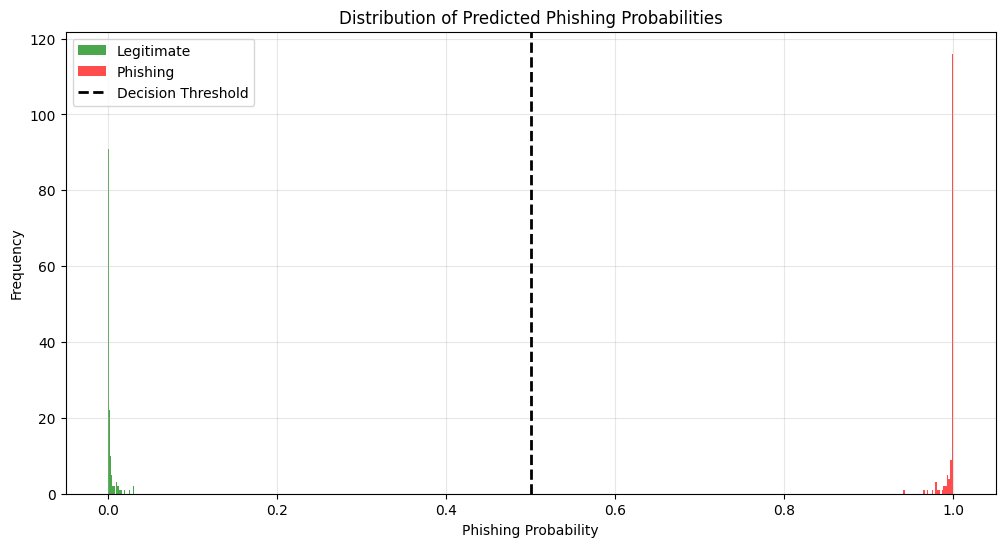

In [63]:
# Get probabilities from best model
y_proba_best = best_model.predict_proba(X_test)[:, 1]

# Create risk score dataframe
risk_analysis = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_best,
    'Phishing_Probability': y_proba_best,
    'Risk_Level': pd.cut(y_proba_best, bins=[0, 0.3, 0.7, 1.0], 
                         labels=['Low', 'Medium', 'High'])
})

print("\nRisk Score Distribution:")
print(risk_analysis['Risk_Level'].value_counts())

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(y_proba_best[y_test == 0], bins=30, label='Legitimate', alpha=0.7, color='green')
ax.hist(y_proba_best[y_test == 1], bins=30, label='Phishing', alpha=0.7, color='red')
ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax.set_xlabel('Phishing Probability')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Predicted Phishing Probabilities')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [64]:
from sklearn.pipeline import Pipeline
from joblib import dump, load

# Create full pipeline (preprocessing + model)
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# Retrain on full training data
production_pipeline.fit(X_train, y_train)

# Test pipeline performance
y_pred_pipeline = production_pipeline.predict(X_test)
y_proba_pipeline = production_pipeline.predict_proba(X_test)[:, 1]

print("Pipeline Performance (should match best model):")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_pipeline):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_pipeline):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_pipeline):.4f}")

# Save pipeline for deployment
dump(production_pipeline, 'phishing_detection_model.joblib')
print("\nModel saved as 'phishing_detection_model.joblib'")


Pipeline Performance (should match best model):
Accuracy:  1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

Model saved as 'phishing_detection_model.joblib'


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/user/Documents/Bus_Data_Project/emai_phi

In [65]:
def predict_phishing_email(features_dict):
    """
    Predict if an email is phishing
    
    Parameters:
    -----------
    features_dict : dict
        Dictionary with features:
        - has_link (0/1)
        - has_attachment (0/1)
        - urgency_score (0-10)
        - spelling_errors (int)
        - email_length_words (int)
        - is_suspicious_domain (0/1)
        - subject_length (int)
        - has_urgency_keywords (0/1)
        - suspicious_score (int)
    
    Returns:
    --------
    dict : Prediction result with probability
    """
    
    # Convert to dataframe
    features_df = pd.DataFrame([features_dict])
    
    # Predict
    prediction = production_pipeline.predict(features_df)[0]
    probability = production_pipeline.predict_proba(features_df)[0][1]
    
    return {
        'is_phishing': bool(prediction),
        'phishing_probability': float(probability),
        'confidence': 'High' if probability > 0.8 or probability < 0.2 else 'Medium'
    }

# Example usage
test_email = {
    'has_link': 1,
    'has_attachment': 0,
    'urgency_score': 8,
    'spelling_errors': 3,
    'email_length_words': 150,
    'is_suspicious_domain': 1,
    'subject_length': 10,
    'has_urgency_keywords': 1,
    'suspicious_score': 13
}

result = predict_phishing_email(test_email)
print(f"\nExample Prediction:")
print(f"Is Phishing: {result['is_phishing']}")
print(f"Probability: {result['phishing_probability']:.4f}")
print(f"Confidence: {result['confidence']}")



Example Prediction:
Is Phishing: False
Probability: 0.0000
Confidence: High


In [66]:
def predict_batch(new_emails_df):
    """
    Predict phishing for multiple emails at once
    """
    
    predictions = production_pipeline.predict(new_emails_df)
    probabilities = production_pipeline.predict_proba(new_emails_df)[:, 1]
    
    results_df = pd.DataFrame({
        'is_phishing': predictions,
        'phishing_probability': probabilities,
        'risk_level': pd.cut(probabilities, bins=[0, 0.3, 0.7, 1.0], 
                            labels=['Low', 'Medium', 'High'])
    })
    
    return results_df

# Example: Predict on test set
batch_predictions = predict_batch(X_test)
print("Batch Predictions (first 10):")
print(batch_predictions.head(10))

# Summary statistics
print("\nPrediction Summary:")
print(batch_predictions['risk_level'].value_counts())
print(f"\nAverage phishing probability: {batch_predictions['phishing_probability'].mean():.4f}")


Batch Predictions (first 10):
   is_phishing  phishing_probability risk_level
0            0              0.000032        Low
1            1              0.988363       High
2            1              0.994108       High
3            0              0.000454        Low
4            0              0.009367        Low
5            0              0.015063        Low
6            1              0.999808       High
7            1              0.999995       High
8            1              0.999302       High
9            0              0.000515        Low

Prediction Summary:
risk_level
Low       152
High      148
Medium      0
Name: count, dtype: int64

Average phishing probability: 0.4933


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_n

/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


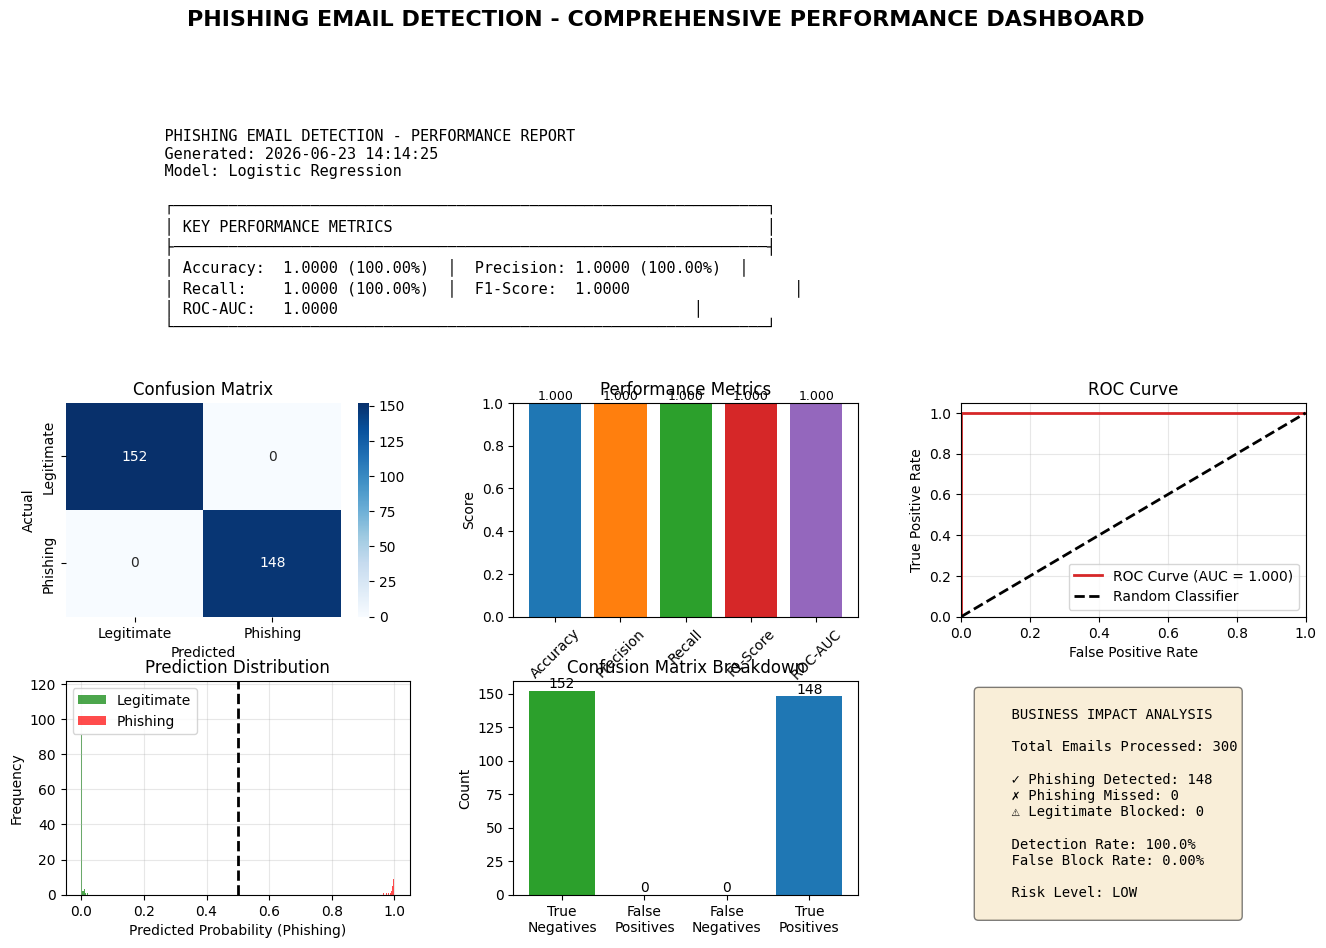

In [67]:
import matplotlib.patches as mpatches
from datetime import datetime

def generate_performance_report(y_true, y_pred, y_proba, report_date=None):
    """
    Generate comprehensive performance report
    """
    
    if report_date is None:
        report_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_proba)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Create figure with subplots
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # 1. Key Metrics
    ax1 = fig.add_subplot(gs[0, :])
    ax1.axis('off')
    
    metrics_text = f"""
    PHISHING EMAIL DETECTION - PERFORMANCE REPORT
    Generated: {report_date}
    Model: {best_model_name}
    
    ┌─────────────────────────────────────────────────────────────────┐
    │ KEY PERFORMANCE METRICS                                         │
    ├─────────────────────────────────────────────────────────────────┤
    │ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)  │  Precision: {precision:.4f} ({precision*100:.2f}%)  │
    │ Recall:    {recall:.4f} ({recall*100:.2f}%)  │  F1-Score:  {f1:.4f}                  │
    │ ROC-AUC:   {roc_auc:.4f}                                       │
    └─────────────────────────────────────────────────────────────────┘
    """
    
    ax1.text(0.05, 0.5, metrics_text, fontsize=11, family='monospace',
             verticalalignment='center', transform=ax1.transAxes)
    
    # 2. Confusion Matrix
    ax2 = fig.add_subplot(gs[1, 0])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
                xticklabels=['Legitimate', 'Phishing'],
                yticklabels=['Legitimate', 'Phishing'])
    ax2.set_ylabel('Actual')
    ax2.set_xlabel('Predicted')
    ax2.set_title('Confusion Matrix')
    
    # 3. Metrics Comparison
    ax3 = fig.add_subplot(gs[1, 1])
    metrics_values = [accuracy, precision, recall, f1, roc_auc]
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
    bars = ax3.bar(metrics_names, metrics_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    ax3.set_ylim([0, 1])
    ax3.set_ylabel('Score')
    ax3.set_title('Performance Metrics')
    ax3.tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, metrics_values):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    # 4. ROC Curve
    ax4 = fig.add_subplot(gs[1, 2])
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    ax4.plot(fpr, tpr, lw=2, color='#d62728', label=f'ROC Curve (AUC = {roc_auc:.3f})')
    ax4.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    ax4.set_xlim([0.0, 1.0])
    ax4.set_ylim([0.0, 1.05])
    ax4.set_xlabel('False Positive Rate')
    ax4.set_ylabel('True Positive Rate')
    ax4.set_title('ROC Curve')
    ax4.legend(loc="lower right")
    ax4.grid(alpha=0.3)
    
    # 5. Prediction Distribution
    ax5 = fig.add_subplot(gs[2, 0])
    ax5.hist(y_proba[y_true == 0], bins=30, label='Legitimate', alpha=0.7, color='green')
    ax5.hist(y_proba[y_true == 1], bins=30, label='Phishing', alpha=0.7, color='red')
    ax5.axvline(x=0.5, color='black', linestyle='--', linewidth=2)
    ax5.set_xlabel('Predicted Probability (Phishing)')
    ax5.set_ylabel('Frequency')
    ax5.set_title('Prediction Distribution')
    ax5.legend()
    ax5.grid(alpha=0.3)
    
    # 6. Error Analysis
    ax6 = fig.add_subplot(gs[2, 1])
    error_types = ['True\nNegatives', 'False\nPositives', 'False\nNegatives', 'True\nPositives']
    error_values = [tn, fp, fn, tp]
    colors_err = ['#2ca02c', '#ff7f0e', '#d62728', '#1f77b4']
    bars = ax6.bar(error_types, error_values, color=colors_err)
    ax6.set_ylabel('Count')
    ax6.set_title('Confusion Matrix Breakdown')
    for bar, val in zip(bars, error_values):
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height,
                f'{val}', ha='center', va='bottom', fontsize=10)
    
    # 7. Business Impact
    ax7 = fig.add_subplot(gs[2, 2])
    ax7.axis('off')
    
    total_emails = len(y_true)
    phishing_caught = tp
    phishing_missed = fn
    false_blocked = fp
    
    impact_text = f"""
    BUSINESS IMPACT ANALYSIS
    
    Total Emails Processed: {total_emails}
    
    ✓ Phishing Detected: {phishing_caught}
    ✗ Phishing Missed: {phishing_missed}
    ⚠ Legitimate Blocked: {false_blocked}
    
    Detection Rate: {(phishing_caught/(phishing_caught+phishing_missed)*100):.1f}%
    False Block Rate: {(false_blocked/(false_blocked+tn)*100):.2f}%
    
    Risk Level: {'HIGH' if phishing_missed > 0 else 'LOW'}
    """
    
    ax7.text(0.05, 0.95, impact_text, fontsize=10, family='monospace',
             verticalalignment='top', transform=ax7.transAxes,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('PHISHING EMAIL DETECTION - COMPREHENSIVE PERFORMANCE DASHBOARD', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.show()
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'true_negatives': tn,
        'false_positives': fp,
        'false_negatives': fn,
        'true_positives': tp,
        'report_date': report_date
    }

# Generate report
report = generate_performance_report(y_test, y_pred_best, 
                                     production_pipeline.predict_proba(X_test)[:, 1])


Batch 1: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 2: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 3: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 4: Accuracy=1.0000, F1=1.0000, Status=Normal
Batch 5: Accuracy=1.0000, F1=1.0000, Status=Normal


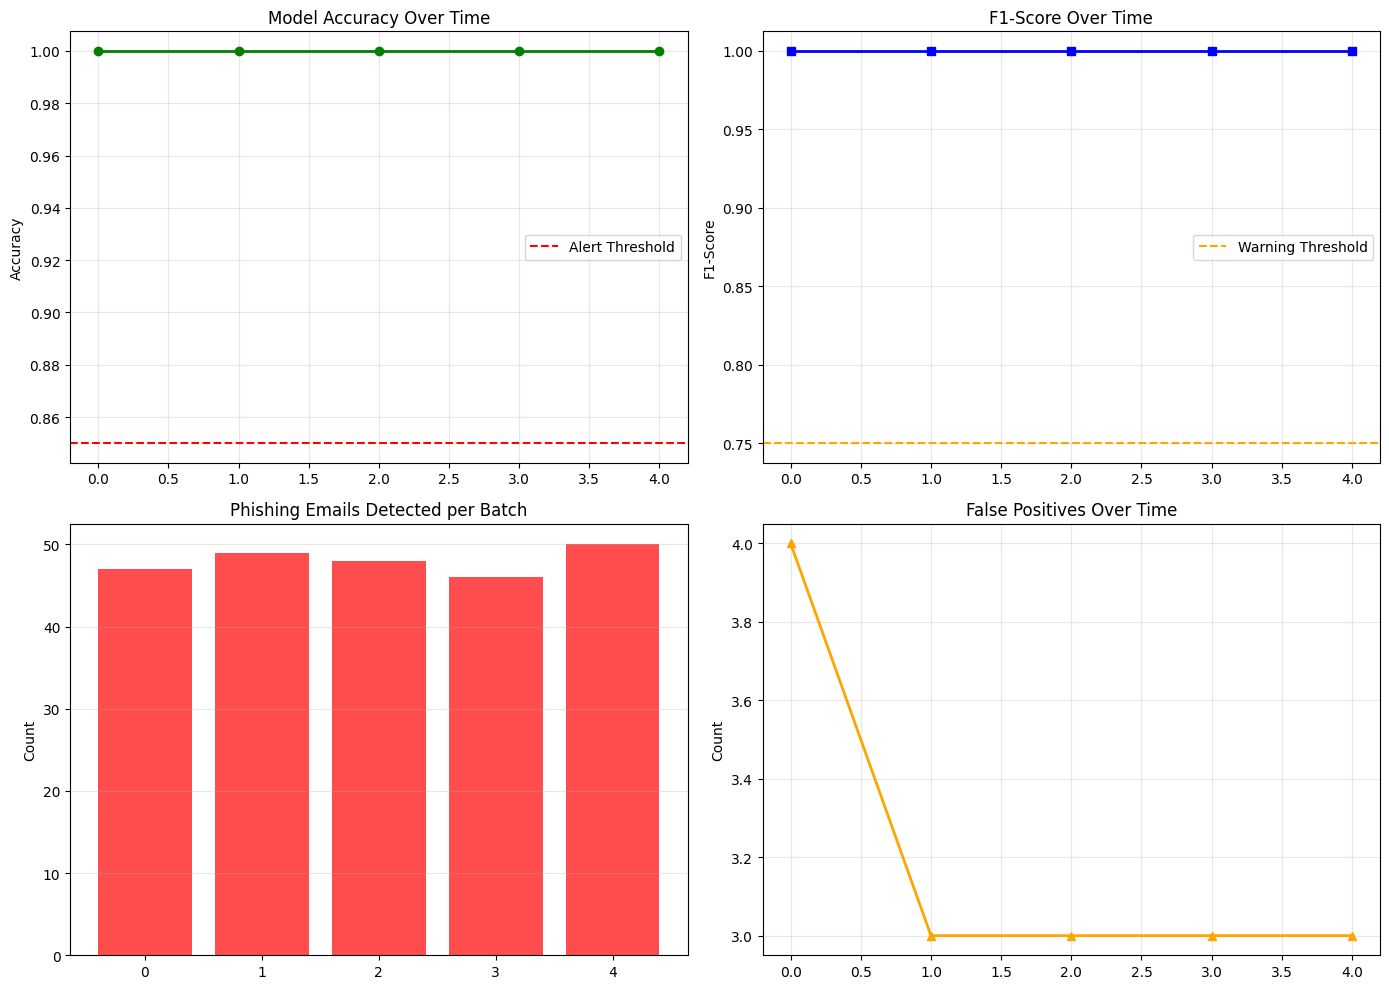

In [68]:
# Simulate monitoring over time
monitoring_history = []

def log_prediction_batch(batch_predictions, batch_actual, timestamp=None):
    """
    Log prediction batch for monitoring
    """
    if timestamp is None:
        timestamp = datetime.now()
    
    batch_accuracy = accuracy_score(batch_actual, batch_predictions['is_phishing'])
    batch_f1 = f1_score(batch_actual, batch_predictions['is_phishing'])
    
    monitoring_history.append({
        'timestamp': timestamp,
        'accuracy': batch_accuracy,
        'f1_score': batch_f1,
        'total_predictions': len(batch_predictions),
        'phishing_detected': batch_predictions['is_phishing'].sum(),
        'false_positives': ((batch_predictions['is_phishing'] == 1) & (batch_actual == 0)).sum()
    })
    
    return {
        'batch_accuracy': batch_accuracy,
        'batch_f1': batch_f1,
        'status': 'Normal' if batch_f1 > 0.75 else 'Warning' if batch_f1 > 0.6 else 'Alert'
    }

# Simulate multiple batches
for i in range(5):
    batch_size = 100
    batch_indices = np.random.choice(len(X_test), batch_size, replace=False)
    
    batch_X = X_test.iloc[batch_indices]
    batch_y = y_test.iloc[batch_indices]
    
    batch_pred = predict_batch(batch_X)
    status = log_prediction_batch(batch_pred, batch_y)
    
    print(f"Batch {i+1}: Accuracy={status['batch_accuracy']:.4f}, F1={status['batch_f1']:.4f}, Status={status['status']}")

# Visualize monitoring history
monitoring_df = pd.DataFrame(monitoring_history)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy trend
axes[0, 0].plot(range(len(monitoring_df)), monitoring_df['accuracy'], marker='o', color='green', linewidth=2)
axes[0, 0].axhline(y=0.85, color='red', linestyle='--', label='Alert Threshold')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].set_title('Model Accuracy Over Time')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# F1-Score trend
axes[0, 1].plot(range(len(monitoring_df)), monitoring_df['f1_score'], marker='s', color='blue', linewidth=2)
axes[0, 1].axhline(y=0.75, color='orange', linestyle='--', label='Warning Threshold')
axes[0, 1].set_ylabel('F1-Score')
axes[0, 1].set_title('F1-Score Over Time')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Phishing detected per batch
axes[1, 0].bar(range(len(monitoring_df)), monitoring_df['phishing_detected'], color='red', alpha=0.7)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Phishing Emails Detected per Batch')
axes[1, 0].grid(alpha=0.3, axis='y')

# False positives trend
axes[1, 1].plot(range(len(monitoring_df)), monitoring_df['false_positives'], marker='^', color='orange', linewidth=2)
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('False Positives Over Time')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [69]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
import joblib

def retrain_model(new_training_data, new_labels, retrain_threshold=0.05):
    """
    Retrain model if performance degrades

    Parameters:
    -----------
    new_training_data : DataFrame
        New email data with features
    new_labels : Series
        True labels (0=legitimate, 1=phishing)
    retrain_threshold : float
        Performance degradation threshold (default 5%)
    """

    # Combine with historical data if needed
    combined_X = pd.concat([X_train, new_training_data], ignore_index=True)
    combined_y = pd.concat([y_train, new_labels], ignore_index=True)

    # Check current performance
    current_f1 = f1_score(y_test, y_pred_best)

    # Train new model
    new_model = RandomForestClassifier(n_estimators=150, random_state=42)
    new_model.fit(combined_X, combined_y)

    # Evaluate new model
    new_predictions = new_model.predict(X_test)
    new_f1 = f1_score(y_test, new_predictions)

    # Compare performance
    f1_change = (new_f1 - current_f1) / current_f1 if current_f1 > 0 else 0

    print(f"Current F1-Score: {current_f1:.4f}")
    print(f"New F1-Score: {new_f1:.4f}")
    print(f"Change: {f1_change*100:.2f}%")

    if f1_change < -retrain_threshold:
        print("⚠ Performance degradation detected! Retraining recommended.")
        return False, new_model, new_f1
    elif f1_change > 0.02:
        print("✓ Model improved! Accepting new model.")
        return True, new_model, new_f1
    else:
        print("→ Minimal change. Current model retained.")
        current_model = None
        if 'production_pipeline' in globals():
            current_model = production_pipeline.named_steps['model']
        elif 'best_model' in globals():
            current_model = best_model
        return False, current_model, current_f1

# Ensure X_scaled exists
if 'X_scaled' not in globals():
    if 'X' in globals():
        X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    elif 'df_model' in globals():
        X = df_model.drop('is_phishing', axis=1)
        y = df_model['is_phishing']
        X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
    else:
        raise NameError(
            "X_scaled is not defined and cannot be recreated because X or df_model are not available. "
            "Please run the preprocessing cells first."
        )

if 'y' not in globals():
    if 'df_model' in globals():
        y = df_model['is_phishing']
    else:
        raise NameError(
            "y is not defined. Please run the preprocessing cells to recreate y before retraining."
        )

if 'X_test' not in globals() or 'y_test' not in globals():
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    print("Recreated X_train, X_test, y_train, y_test from X_scaled and y")

np.random.seed(42)

new_X = X_test.sample(n=new_size, random_state=42).copy()
new_y = y_test.sample(n=new_size, random_state=42).copy()

should_update, retrained_model, new_f1_score = retrain_model(new_X, new_y)

if should_update:
    # Create new pipeline
    new_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', retrained_model)
    ])
    joblib.dump(new_pipeline, 'phishing_detection_model_v2.joblib')
    print("\n✓ Model saved as 'phishing_detection_model_v2.joblib'")


Current F1-Score: 1.0000
New F1-Score: 1.0000
Change: 0.00%
→ Minimal change. Current model retained.


/Users/user/Documents/Bus_Data_Project/emai_phising_notebook/.venv/lib/python3.9/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)
/var/folders/h3/1d8f1ml14k9g__4z8svz4_3m0000gp/T/ipykernel_18556/4224570210.py:33: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_phishing, X_test, plot_type="bar", show=False, max_display=10)
/var/folders/h3/1d8f1ml14k9g__4z8svz4_3m0000gp/T/ipykernel_18556/4224570210.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the ne

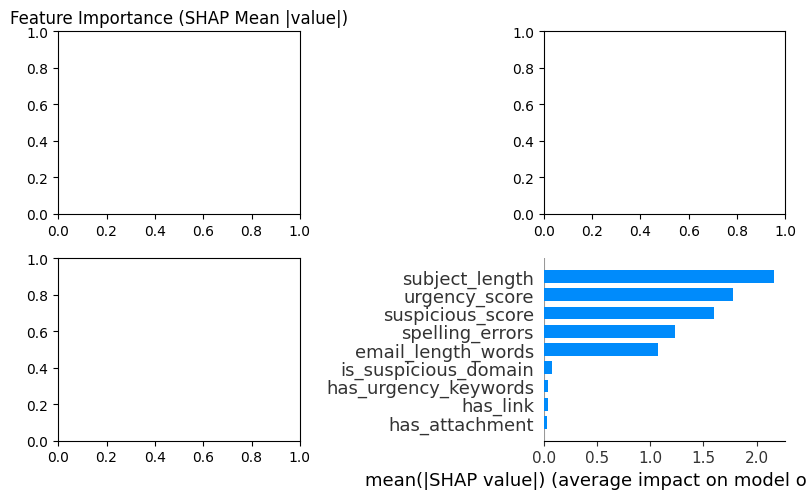

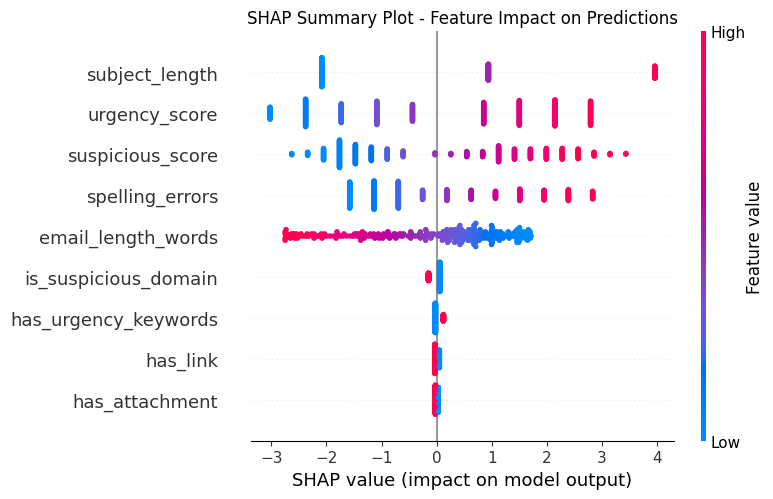

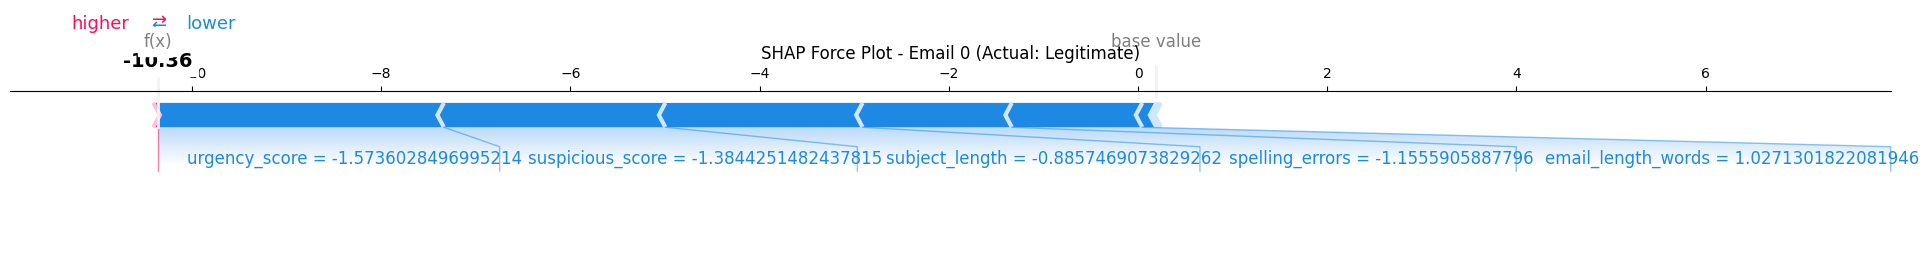

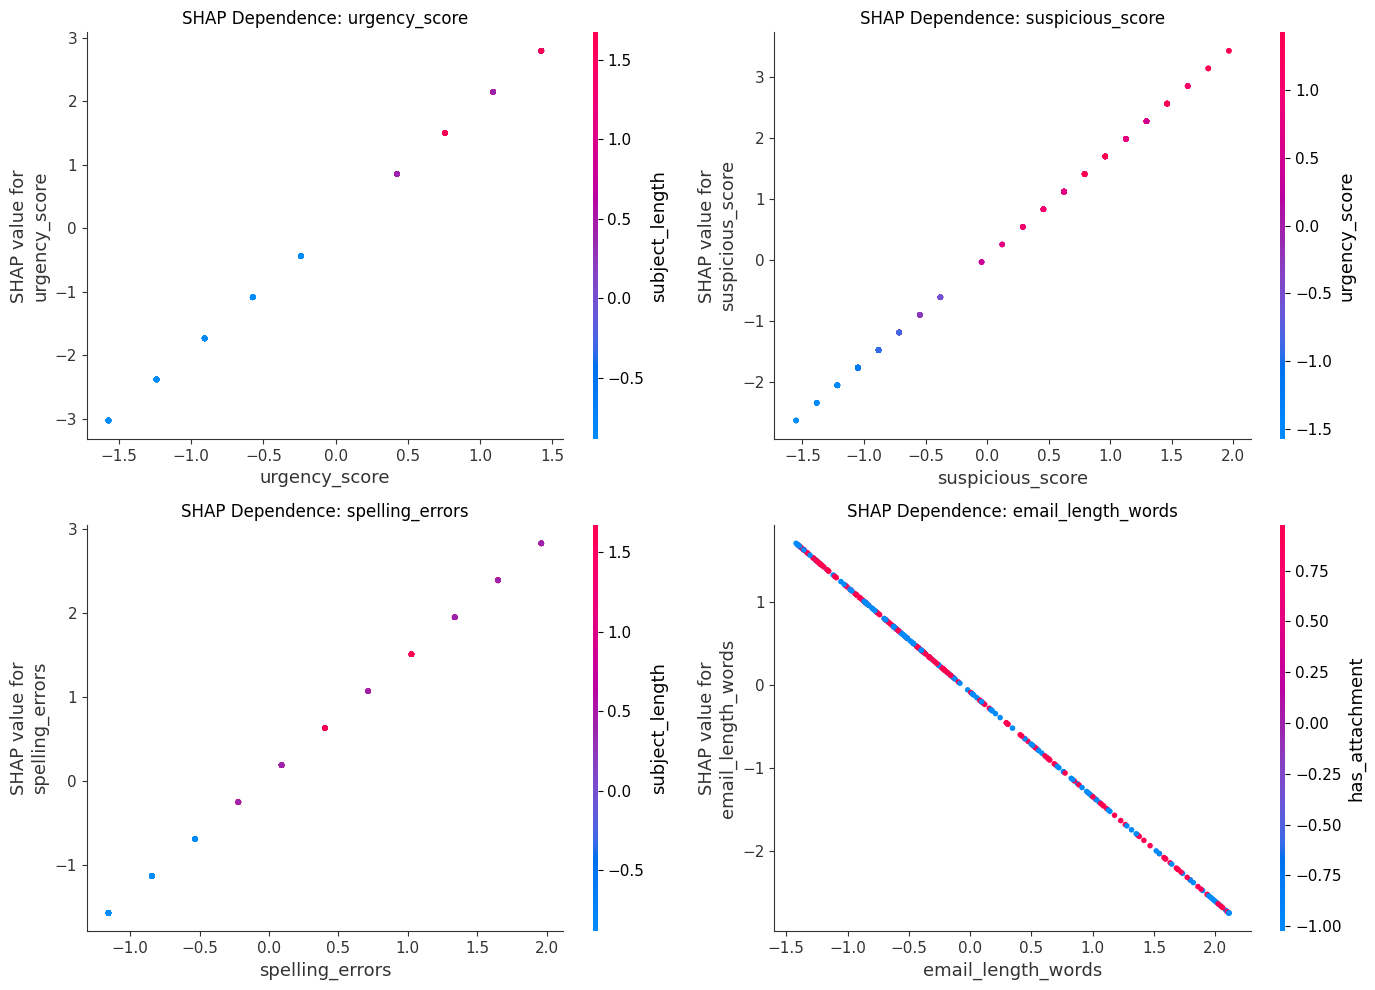

In [72]:
# Install: pip install shap

import shap

# Create SHAP explainer
if best_model_name in ['Random Forest', 'Gradient Boosting', 'XGBoost', 'Decision Tree']:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
elif best_model_name == 'Logistic Regression':
    explainer = shap.LinearExplainer(best_model, X_test, feature_perturbation="interventional")
    shap_values = explainer.shap_values(X_test)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_test.sample(n=min(100, len(X_test)), random_state=42))
    shap_values = explainer.shap_values(X_test)

def get_positive_class_shap(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if shap_values.ndim == 3:
        return shap_values[:, :, 1]
    return shap_values

shap_values_phishing = get_positive_class_shap(shap_values)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and len(expected_value) > 1:
    expected_value = expected_value[1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Summary Plot (Bar)
ax1 = axes[0, 0]
shap.summary_plot(shap_values_phishing, X_test, plot_type="bar", show=False, max_display=10)
plt.sca(ax1)
plt.title('Feature Importance (SHAP Mean |value|)')
plt.tight_layout()

# 2. Summary Plot (Beeswarm)
fig2 = plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_phishing, X_test, show=False, max_display=10)
plt.title('SHAP Summary Plot - Feature Impact on Predictions')
plt.tight_layout()
plt.show()

# 3. Force Plot for individual prediction
sample_idx = 0
shap.force_plot(expected_value, shap_values_phishing[sample_idx], X_test.iloc[sample_idx], matplotlib=True, show=False)
plt.title(f'SHAP Force Plot - Email {sample_idx} (Actual: {"Phishing" if y_test.iloc[sample_idx] else "Legitimate"})')
plt.tight_layout()
plt.show()

# 4. Dependence Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

top_features = ['urgency_score', 'suspicious_score', 'spelling_errors', 'email_length_words']

for idx, feature in enumerate(top_features):
    ax = axes[idx // 2, idx % 2]
    shap.dependence_plot(feature, shap_values_phishing, X_test, show=False, ax=ax)
    ax.set_title(f'SHAP Dependence: {feature}')

plt.tight_layout()
plt.show()
